In [19]:
from __future__ import annotations

import gzip
import struct
import urllib.request
import matplotlib.pyplot as plt
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw

In [3]:
MNIST_FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images": "t10k-images-idx3-ubyte.gz",
    "test_labels": "t10k-labels-idx1-ubyte.gz",
}

MNIST_BASE_URL = "https://storage.googleapis.com/cvdf-datasets/mnist/"
DATA_DIR = Path("data/mnist")
PREVIEW_PATH = DATA_DIR / "mnist_preview.png"

In [4]:
def download_file(filename: str, destination: Path) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists():
        print(f"Using cached file: {destination}")
        return

    url = MNIST_BASE_URL + filename
    print(f"Downloading {url} -> {destination}")
    urllib.request.urlretrieve(url, destination)

In [5]:
def parse_images(path: Path) -> np.ndarray:
    with gzip.open(path, "rb") as handle:
        magic, count, rows, cols = struct.unpack(">IIII", handle.read(16))
        if magic != 2051:
            raise ValueError(
                f"Unexpected image magic number in {path}: {magic}")
        data = np.frombuffer(handle.read(), dtype=np.uint8)
    return data.reshape(count, rows, cols)


def parse_labels(path: Path) -> np.ndarray:
    with gzip.open(path, "rb") as handle:
        magic, count = struct.unpack(">II", handle.read(8))
        if magic != 2049:
            raise ValueError(
                f"Unexpected label magic number in {path}: {magic}")
        data = np.frombuffer(handle.read(), dtype=np.uint8)
    if len(data) != count:
        raise ValueError(
            f"Label count mismatch in {path}: expected {count}, got {len(data)}")
    return data

In [6]:
def load_mnist(data_dir: Path = DATA_DIR) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    paths = {key: data_dir / filename for key, filename in MNIST_FILES.items()}

    for filename in MNIST_FILES.values():
        download_file(filename, data_dir / filename)

    x_train = parse_images(paths["train_images"])
    y_train = parse_labels(paths["train_labels"])
    x_test = parse_images(paths["test_images"])
    y_test = parse_labels(paths["test_labels"])
    return x_train, y_train, x_test, y_test

In [7]:
def create_preview_grid(
    images: np.ndarray,
    labels: np.ndarray,
    destination: Path,
    count: int = 12,
    columns: int = 4,
    scale: int = 6,
    padding: int = 18,
) -> None:
    count = min(count, len(images))
    rows = (count + columns - 1) // columns
    digit_size = images.shape[1] * scale
    canvas_width = columns * digit_size
    canvas_height = rows * (digit_size + padding)

    canvas = Image.new("L", (canvas_width, canvas_height), color=255)
    draw = ImageDraw.Draw(canvas)

    for idx in range(count):
        row, col = divmod(idx, columns)
        x0 = col * digit_size
        y0 = row * (digit_size + padding)
        digit = Image.fromarray(images[idx], mode="L").resize(
            (digit_size, digit_size), resample=Image.Resampling.NEAREST
        )
        canvas.paste(digit, (x0, y0))
        draw.text((x0, y0 + digit_size + 2),
                  f"label={int(labels[idx])}", fill=0)

    destination.parent.mkdir(parents=True, exist_ok=True)
    canvas.save(destination)
    print(f"Saved preview image: {destination}")

In [8]:
x_train, y_train, x_test, y_test = load_mnist()

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [11]:
create_preview_grid(x_train, y_train, PREVIEW_PATH)
#Image.open(PREVIEW_PATH)

Saved preview image: data/mnist/mnist_preview.png


Below we partition the training data (x_train) via its label (y_train) and we reshape each 28 by 28 image to be a 28*28 = 784 row vector.

In [23]:
digits_flat = {d: x_train[y_train == d].reshape(
    x_train[y_train == d].shape[0], 28 * 28) for d in range(10)}

For each digit we perform SVD on the "digit matrix" by which I mean each row of this matrix is one 784 instance of the digit. The top/principal singular row vectors thus become representatives of the digit.

In [24]:
svds = {d: np.linalg.svd(
    digits_flat[d], full_matrices=False) for d in range(10)}


In [27]:
Vh0 = svds[0][2]
Vh1 = svds[1][2]
Vh2 = svds[2][2]
Vh3 = svds[3][2]
Vh4 = svds[4][2]
Vh5 = svds[5][2]
Vh6 = svds[6][2]
Vh7 = svds[7][2]
Vh8 = svds[8][2]
Vh9 = svds[9][2]
Vh0.shape

(784, 784)

In [37]:
def show_pc_grid(Vhk, digit, rows=2, cols=3):
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))

    for j, ax in enumerate(axes.flat):
        ax.imshow(Vhk[j].reshape(28, 28), cmap="gray")
        ax.set_title(f"PC {j}")
        ax.axis("off")

    
    fig.suptitle(f"Top {rows*cols} Principal Components for Digit {digit}")
    plt.tight_layout()
    plt.show()

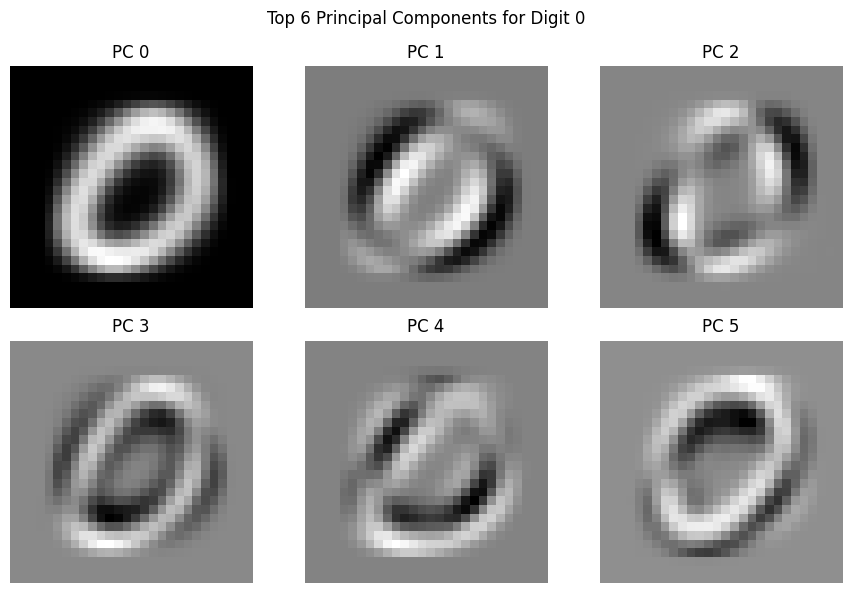

In [ ]:
show_pc_grid(Vh0, 0)

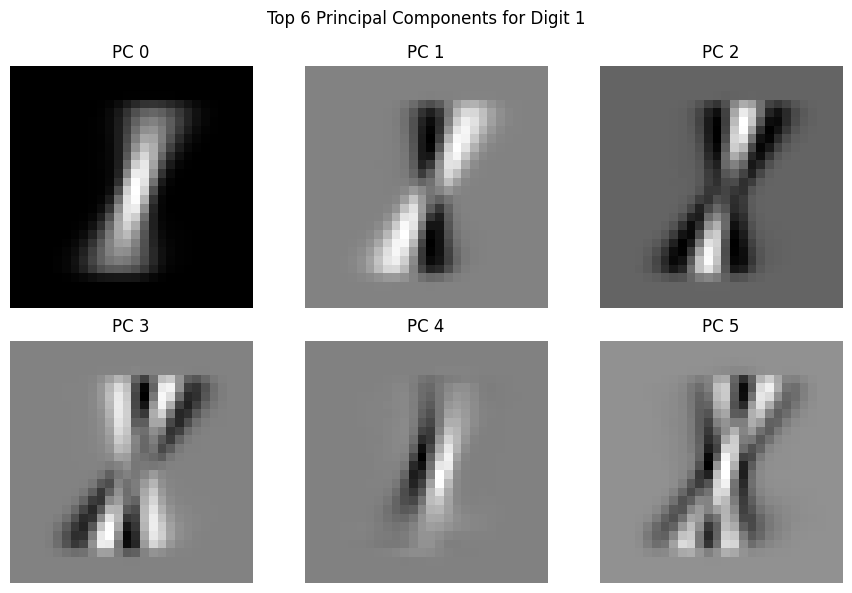

In [39]:
show_pc_grid(Vh1, 1)

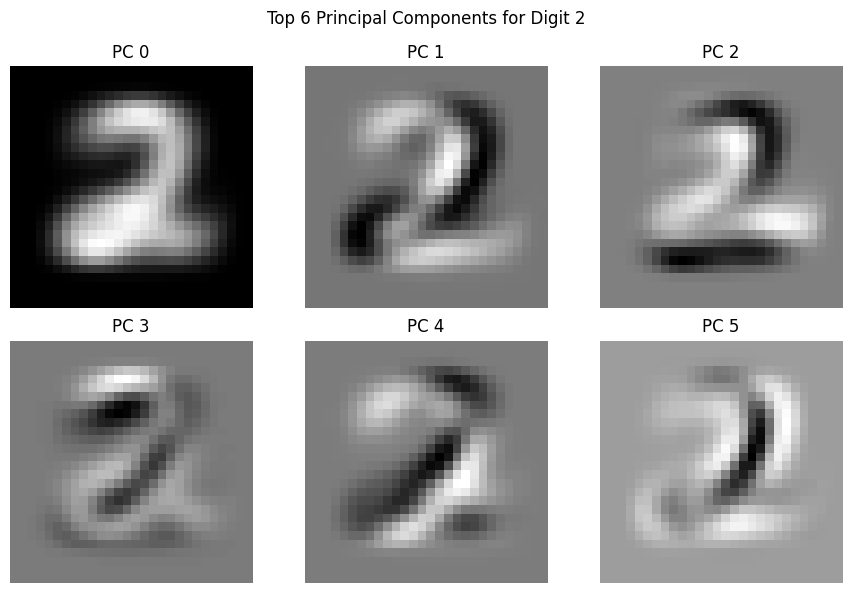

In [40]:
show_pc_grid(Vh2, 2)

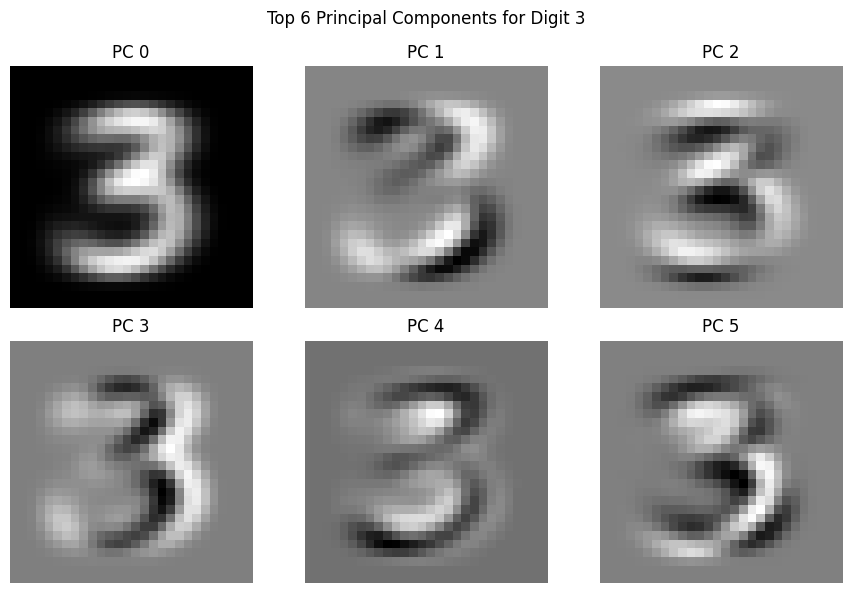

In [41]:
show_pc_grid(Vh3, 3)